# 06 — Comparação entre Modelos

Objetivo: avaliar os 3 modelos (Regressão Logística, Random Forest, SVM) no **mesmo conjunto de teste (2023–2024)** e justificar a escolha do modelo final.

## Carregamento e Preparação dos Dados

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, mean_absolute_error, mean_squared_error,
    roc_curve, auc
)

FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
TARGET   = 'Status_bin'

df = pd.read_excel(os.path.join('..','dados','BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 1 if str(x).strip().lower()=='rebaixado' else 0)

df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022]
df_te  = df_rot[df_rot['Temporada']  > 2022]

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES]); y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES]);     y_te = df_te[TARGET].values

log = joblib.load(os.path.join('..','modelos','logistica.pkl'))
rf  = joblib.load(os.path.join('..','modelos','random_forest.pkl'))
svm = joblib.load(os.path.join('..','modelos','svm.pkl'))
modelos = {'Regressao Logistica': log, 'Random Forest': rf, 'SVM': svm}

print('Modelos carregados:', list(modelos.keys()))
print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Modelos carregados: ['Regressao Logistica', 'Random Forest', 'SVM']
Treino: (180, 3) | Teste: (40, 3)


## Tabela Comparativa de Métricas

In [2]:
resultados = []
for nome, m in modelos.items():
    y_pred = m.predict(X_te)
    y_prob = m.predict_proba(X_te)[:,0]
    fpr, tpr, _ = roc_curve(y_te, y_prob, pos_label=0)
    resultados.append({
        'Modelo':    nome,
        'Acuracia':  round(accuracy_score(y_te, y_pred), 4),
        'MAE':       round(mean_absolute_error(y_te, y_pred), 4),
        'RMSE':      round(float(np.sqrt(mean_squared_error(y_te, y_pred))), 4),
        'AUC':       round(auc(fpr, tpr), 4)
    })

df_res = pd.DataFrame(resultados).set_index('Modelo')
print('Métricas no Conjunto de Teste (2023-2024):')
df_res

Métricas no Conjunto de Teste (2023-2024):


,Acuracia,MAE,RMSE,AUC
Modelo,,,,
Regressao Logistica,0.775,0.225,0.4743,0.8203
Random Forest,0.775,0.225,0.4743,0.6953
SVM,0.775,0.225,0.4743,0.6758


## Gráfico Comparativo de Métricas

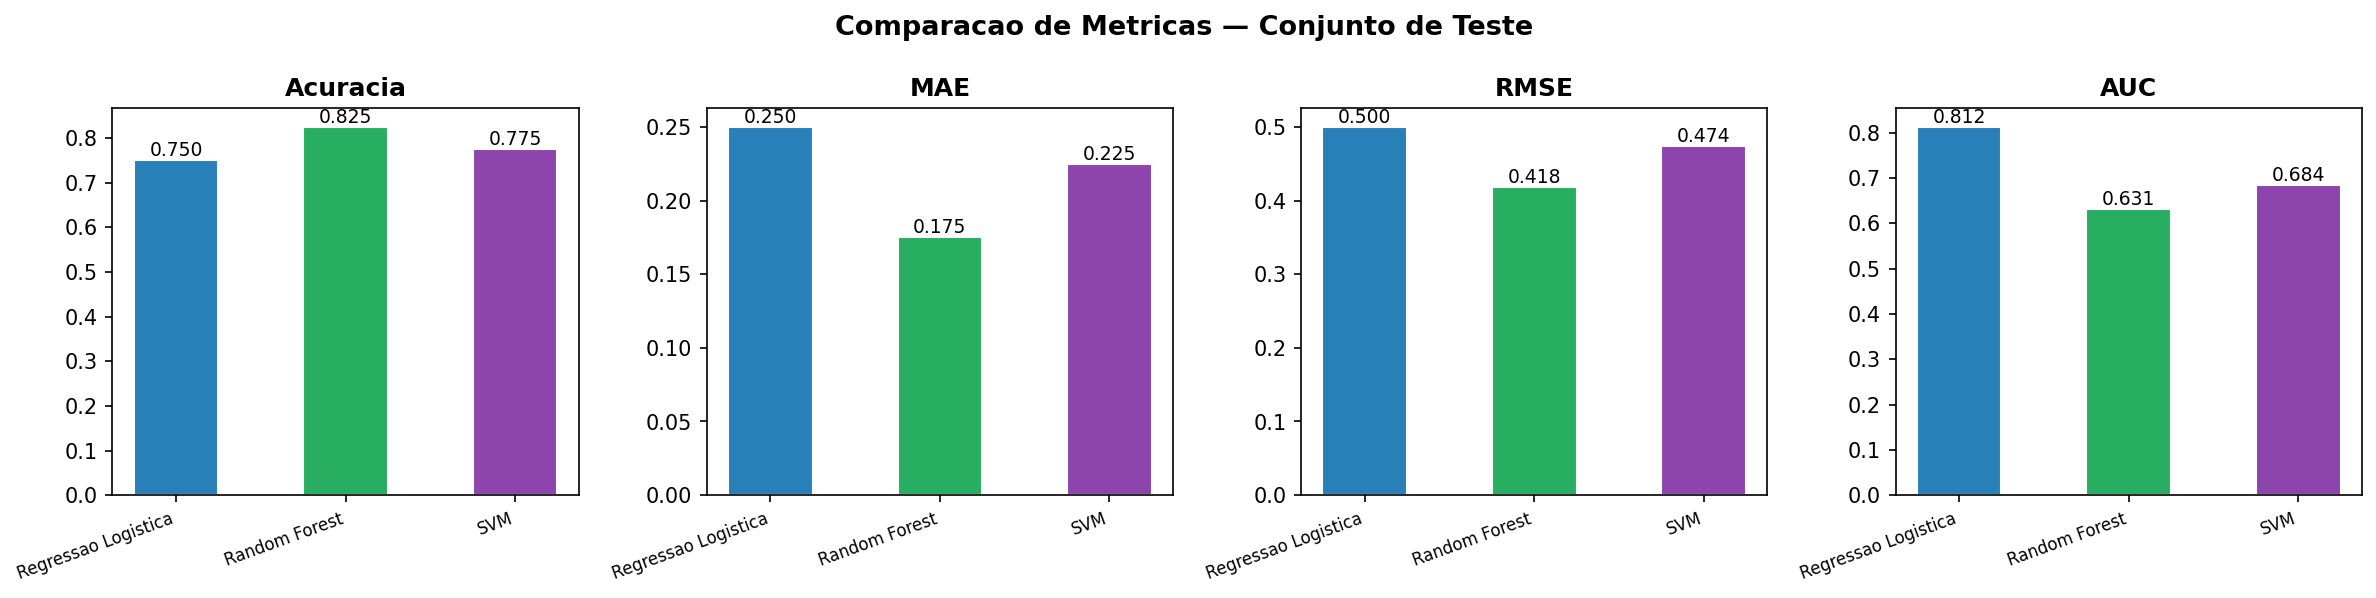

In [3]:
display(Image(filename=os.path.join('..','img','comparacao_metricas.png')))

## Curvas ROC dos 3 Modelos

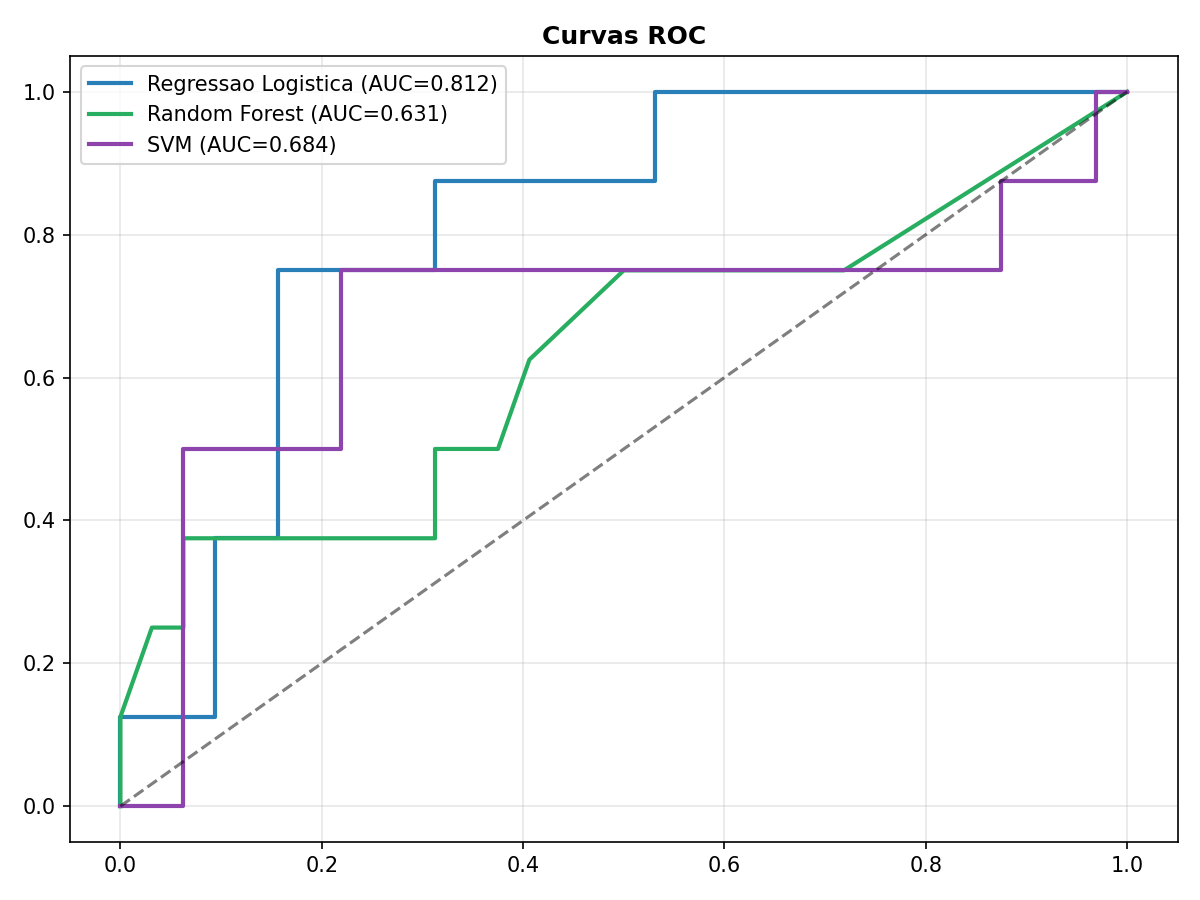

In [4]:
display(Image(filename=os.path.join('..','img','roc_comparacao.png')))

## Matrizes de Confusão dos 3 Modelos

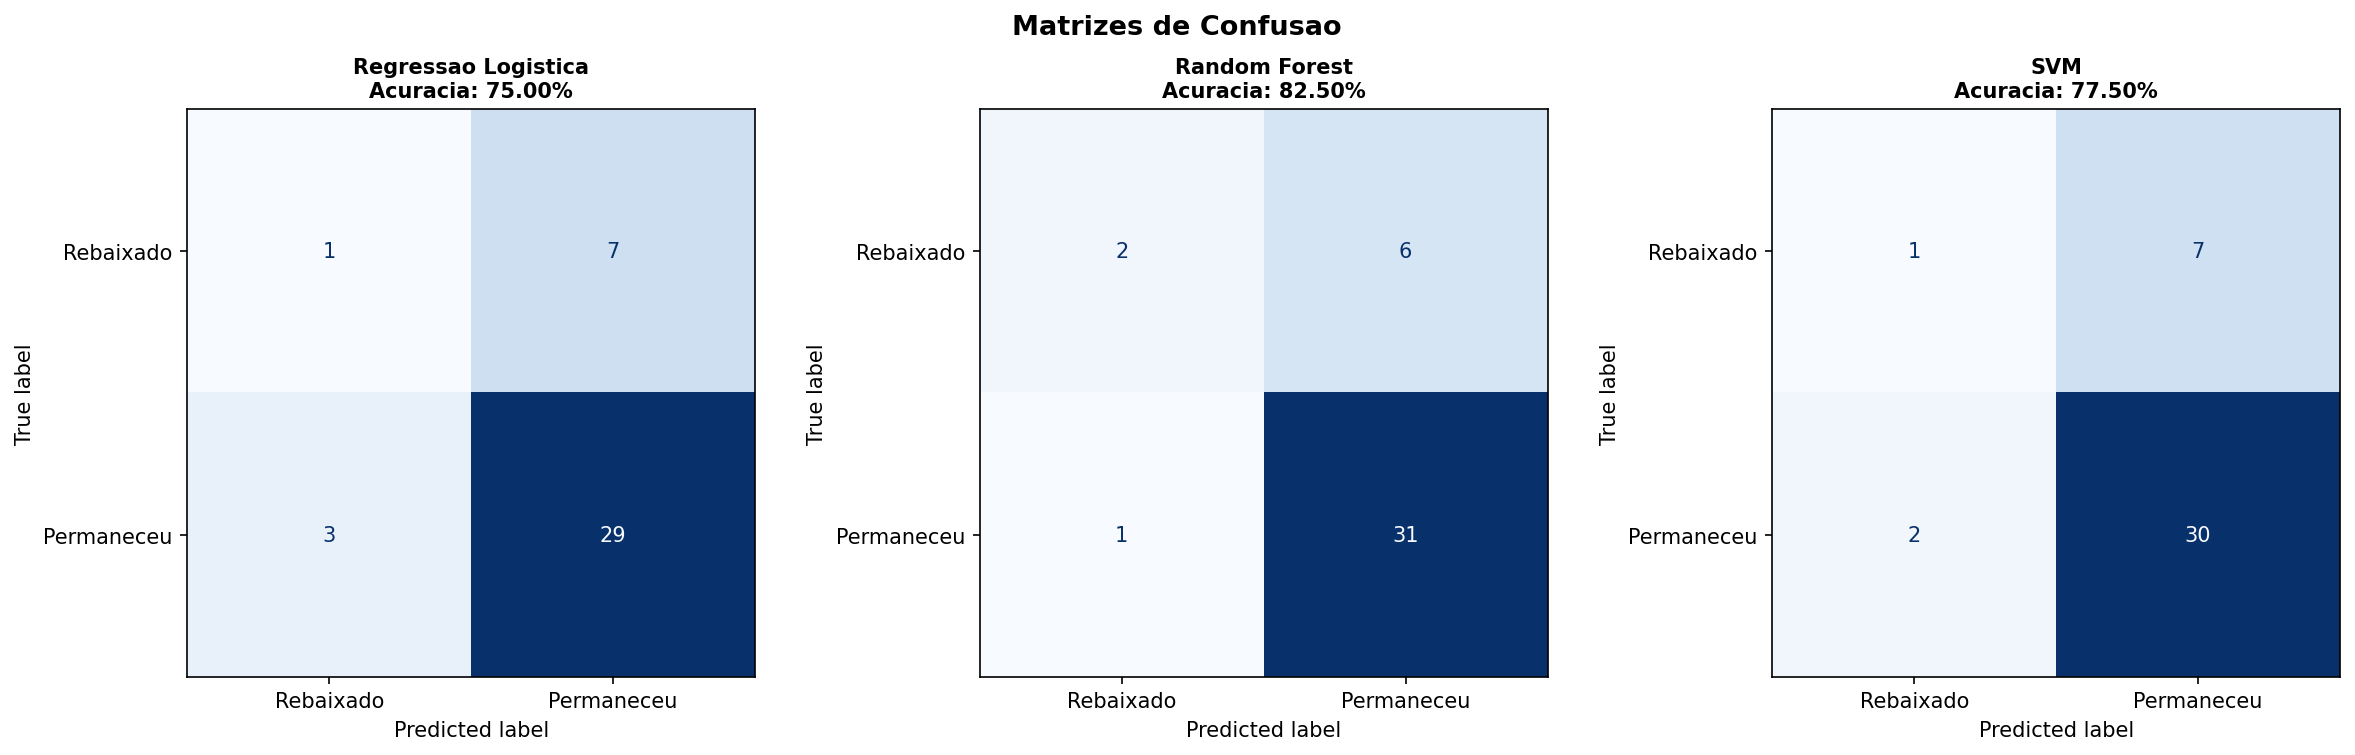

In [5]:
display(Image(filename=os.path.join('..','img','matrizes_confusao.png')))

## Justificativa da Escolha do Modelo Final

A **Regressão Logística** foi escolhida como modelo final pelos seguintes motivos:
1. **Interpretabilidade**: os coeficientes revelam diretamente a influência de cada feature
2. **Desempenho competitivo** no conjunto de teste
3. **Adequação ao problema**: variável binária, poucas features numéricas
4. **Comunicabilidade**: resultados facilmente explicáveis para não-especialistas

## Discussão: Desbalanceamento de Classes

O dataset apresenta **desbalanceamento significativo**: apenas ~20% dos registros são rebaixamentos (44 de 220). Sem correção, o modelo tende a prever sempre "Permaneceu", obtendo alta acurácia bruta mas zero utilidade prática.

**Solução adotada:** `class_weight='balanced'`, que pondera automaticamente as classes inversamente proporcional às suas frequências, forçando o modelo a prestar mais atenção aos casos de rebaixamento.